# Data preparation and filtering of original dataset to use for the Neural Network

Transparency is important so I'm showing all my steps for the data preparation. The original dataset with images is too large to include in the GitHub, so you need to download it yourself. Make sure you store it somewhere where you can access it via a path.


In [8]:
pip install albumentations --user

  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
Using cached albumentations-2.0.8-py3-none-any.whl (369 kB)
Using cached albucore-0.0.24-py3-none-any.whl (15 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl (40.1 MB)
Using cached pydantic-2.13.4-py3-none-any.whl (472 kB)
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)

   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------------------------

In [6]:
import pandas as pd
from pathlib import Path
import json 
import numpy as np
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2

# check for model running: 
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
#print(torch.cuda.get_device_name(0))
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

2.12.0+cpu
None
False


In [8]:
# -- IMPORTING ALL NON-IMAGE DATA -- #
# ground truth segmentations per img
seg = pd.read_csv("Radiology_hand_drawn_segmentations_v2.csv")
# anottations per img
annot = pd.read_excel("Radiology-manual-annotations.xlsx")

# The segmentation is sorted by the column called #filename. Annot is sorted by the column Image_name
# The only difference about these two is that #filename has .jpg after each entry. 
# So i'm removing that 

seg["#filename"] = seg["#filename"].str.replace(".jpg", "")

# Analysing values in seg:
# Using print(seg['COLUMNNAME'].unique()) I figured out that the columns region_attributes and file_attributes only contain {}. 
# I also don't think that the column "file_size" will be of any use. We can always change this if one of them is needed later.
seg = seg.drop(columns = ["file_attributes", "region_attributes", "file_size"])

# -- IMPORTING IMAGE DATA -- #
# Make sure you have the images dataset folder downloaded and saved in program files.
# Or change the path stuff around. 

# Due to python tweaking if you put in the raw path files with \, 
# put r in front of the string to treat it as raw string
imgs_locations = [Path(r"C:\Users\aryan\SysteemProject\data\PKG - CDD-CESM\CDD-CESM\Subtracted images of CDD-CESM")]

print(seg)
print(annot)
print(imgs_locations)
rows = []
for folder in imgs_locations:
    for img in folder.glob("*.jpg"):  # only get images and not the desktop.ini file
        rows.append({"image_id": img.stem, "image_path": str(img)})
images_df = pd.DataFrame(rows)

# Time for the full dataset? Yeahhh
dataset = (images_df
           .merge(annot, left_on = "image_id", right_on = "Image_name", how = "left")
           .merge(seg, left_on = "image_id", right_on = "#filename", how = "left"))

dataset["patient_id"] = dataset["image_id"].str.extract(r"(P\d+)")
dataset = dataset.drop(columns = ["Patient_ID", "Image_name"])
dataset

          #filename  region_count  region_id  \
0       P1_L_CM_MLO             1          0   
1       P1_L_DM_MLO             1          0   
2        P2_L_CM_CC             1          0   
3       P2_L_CM_MLO             1          0   
4        P2_L_DM_CC             4          0   
...             ...           ...        ...   
2966  P326_L_CM_MLO             1          0   
2967   P326_L_DM_CC             1          0   
2968  P326_L_DM_MLO             1          0   
2969   P326_R_DM_CC             1          0   
2970  P326_R_DM_MLO             1          0   

                                region_shape_attributes  
0     {"name":"polygon","all_points_x":[350,423,1005...  
1     {"name":"polygon","all_points_x":[353,413,1033...  
2     {"name":"polygon","all_points_x":[550,533,412,...  
3     {"name":"polygon","all_points_x":[26,954,945,8...  
4     {"name":"polygon","all_points_x":[4,107,349,49...  
...                                                 ...  
2966  {"name":"po

,image_id,image_path,Side,Type,Age,Breast density (ACR),BIRADS,Findings,View,Tags,Machine,Pathology Classification/ Follow up,#filename,region_count,region_id,region_shape_attributes,patient_id
0,P100_L_CM_CC,C:\Users\aryan\SysteemProject\data\PKG - CDD-C...,L,CESM,61.0,_,2,Non enhancement,CC,postoperative,1.0,Benign,P100_L_CM_CC,1.0,0.0,"{""name"":""polygon"",""all_points_x"":[187,258,202,...",P100
1,P100_L_CM_MLO,C:\Users\aryan\SysteemProject\data\PKG - CDD-C...,L,CESM,61.0,_,2,Non enhancement,MLO,postoperative,1.0,Benign,P100_L_CM_MLO,1.0,0.0,"{""name"":""polygon"",""all_points_x"":[138,326,494,...",P100
2,P100_R_CM_CC,C:\Users\aryan\SysteemProject\data\PKG - CDD-C...,R,CESM,61.0,_,1,No mass or non mass enhancement,CC,normal,1.0,Normal,NaN,NaN,NaN,NaN,P100
3,P100_R_CM_MLO,C:\Users\aryan\SysteemProject\data\PKG - CDD-C...,R,CESM,61.0,_,1,No mass or non mass enhancement,MLO,normal,1.0,Normal,NaN,NaN,NaN,NaN,P100
4,P101_L_CM_CC,C:\Users\aryan\SysteemProject\data\PKG - CDD-C...,L,CESM,47.0,_,1,No mass or non mass enhancement,CC,normal,1.0,Normal,NaN,NaN,NaN,NaN,P101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,P99_L_CM_MLO,C:\Users\aryan\SysteemProject\data\PKG - CDD-C...,L,CESM,61.0,_,1,No mass or non mass enhancement,MLO,normal,1.0,Normal,NaN,NaN,NaN,NaN,P99
1597,P99_L_CM_MLO_2,C:\Users\aryan\SysteemProject\data\PKG - CDD-C...,L,CESM,61.0,_,1,No mass or non mass enhancement,MLO,normal,1.0,Normal,NaN,NaN,NaN,NaN,P99
1598,P99_R_CM_CC,C:\Users\aryan\SysteemProject\data\PKG - CDD-C...,R,CESM,61.0,_,5,Heterogenously enhancing mass with irregular m...,CC,"malignant mass, heterogenous, irregular",1.0,Malignant,P99_R_CM_CC,1.0,0.0,"{""name"":""polygon"",""all_points_x"":[2376,2326,22...",P99
1599,P99_R_CM_MLO,C:\Users\aryan\SysteemProject\data\PKG - CDD-C...,R,CESM,61.0,_,5,Heterogenously enhancing mass with irregular m...,MLO,"malignant mass, heterogenous, irregular",1.0,Malignant,P99_R_CM_MLO,1.0,0.0,"{""name"":""polygon"",""all_points_x"":[1656,1693,17...",P99


In [10]:
# -- Mask time for ground truth -- #

def create_mask(image_path, annot):
    """
    Creates a binary mask based on region shape attributes for an image, to use as truth.
    """
    img = np.array(Image.open(image_path))
    height, width = img.shape[:2]

    # mask should contain all 0's with 1 for identified tumors 
    mask = np.zeros((height, width), dtype=np.uint8) 

    for annotation in annot.dropna():
        shape = json.loads(annotation) # annotation is currently json so no more

        # -- We gotta keep the different shapes of annotations in mind! -- #
        # Seems like polygon, ellipse and circle are the ones used.
        shape_type = shape.get("name")

        if shape_type == "polygon":
            points = np.array(
                list(zip(shape["all_points_x"], shape["all_points_y"])),dtype=np.int32)
            cv2.fillPoly(mask, [points], 1)  # cv fillpoly is made for the polys

        elif shape_type == "circle":
            cv2.circle(mask,
                (shape["cx"], shape["cy"]), shape["r"],1, -1) # we can change color & thickness to outlines only, but i dont think we should

        elif shape_type == "ellipse":
            cv2.ellipse(
                mask,(shape["cx"], shape["cy"]),(shape["rx"], shape["ry"]), 0, 0,360, 1, -1)

    return mask

# -- Creating a new folder with all the masks per scan -- #

mask_folder = Path("masks_subtracted")
mask_folder.mkdir(exist_ok=True)
grouped = dataset.groupby("image_id")
for image_id, group in grouped:

    if group["region_shape_attributes"].isna().all():
        continue

    image_path = group["image_path"].iloc[0]
    mask = create_mask(image_path, group["region_shape_attributes"])

    cv2.imwrite(str(mask_folder / f"{image_id}_subtracted_mask.jpg"), mask * 255)


In [9]:
# To prevent errors later on during training, the images without masks need to be removed.

valid_ids = []

for image_id in dataset["image_id"].unique():
    if Path(f"masks/{image_id}_mask.jpg").exists():
        valid_ids.append(image_id)

dataset = dataset[dataset["image_id"].isin(valid_ids)]

# Splitting
**Train** 70%

**Validation** 15%

**Test** 15%

In [10]:
patients = dataset["patient_id"].unique()
train_patients, test_patients = train_test_split(
    patients,
    test_size=0.10,   
    random_state=42,
    shuffle=True
)
#build dataframes (use dataset, not df)
df_trainval = dataset[dataset["patient_id"].isin(train_patients)]
# Don't touch this till the end
df_test = dataset[dataset["patient_id"].isin(test_patients)]
# safety check (so hopefully leakage)
assert set(df_trainval.patient_id).isdisjoint(set(df_test.patient_id))

#sizes
print("Train/Val:", len(df_trainval))
print("Test:", len(df_test))

Train/Val: 1022
Test: 152


In [34]:
class CombinedLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds_sig    = torch.sigmoid(preds)
        preds_flat   = preds_sig.view(-1)
        targets_flat = targets.view(-1)
        intersection = (preds_flat * targets_flat).sum()
        dice_loss    = 1 - (2. * intersection + self.smooth) / (
                       preds_flat.sum() + targets_flat.sum() + self.smooth)

        bce_loss = F.binary_cross_entropy_with_logits(preds, targets)

        return 0.7 * dice_loss + 0.3 * bce_loss

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ElasticTransform(p=0.2),
])

class BreastDataset(Dataset):
    def __init__(self, df, augment=False):  # ← augment flag toegevoegd
        self.df      = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img       = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
        mask_path = f"masks_subtracted/{row['image_id']}_subtracted_mask.jpg"
        mask      = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        target_size = (256, 256)
        img  = cv2.resize(img,  target_size, interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)

        if img is None or mask is None:
            raise ValueError("Missing image or mask")

        # Augmentatie alleen op trainset
        if self.augment:
            augmented = transform(image=img, mask=mask)
            img  = augmented["image"]
            mask = augmented["mask"]

        img  = img.astype(np.float32) / 255.0
        mask = (mask > 0).astype(np.float32)

        img  = np.expand_dims(img,  0)
        mask = np.expand_dims(mask, 0)

        return torch.tensor(img), torch.tensor(mask)

# OKE DUS dit is ons originele UNET model. Ik wil m niet wegdoen dus maak ik van deze cell een markdown.
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):

        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        x4 = self.down4(self.pool(x3))

        x5 = self.bottleneck(self.pool(x4))

        x = self.up4(x5)
        x = torch.cat([x, x4], dim=1)
        x = self.conv4(x)

        x = self.up3(x)
        x = torch.cat([x, x3], dim=1)
        x = self.conv3(x)

        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv2(x)

        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv1(x)

        return self.out(x)



In [12]:
class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super(SelfAttention, self).__init__()
        self.query_conv = nn.Conv2d(in_channels=in_dim, out_channels=max(1, in_dim // 8), kernel_size=1)
        self.key_conv   = nn.Conv2d(in_channels=in_dim, out_channels=max(1, in_dim // 8), kernel_size=1)
        self.value_conv = nn.Conv2d(in_channels=in_dim, out_channels=in_dim, kernel_size=1)
        self.gamma      = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        m_batchsize, C, width, height = x.size()
        proj_query = self.query_conv(x).view(m_batchsize, -1, width * height).permute(0, 2, 1)
        proj_key   = self.key_conv(x).view(m_batchsize, -1, width * height)
        energy     = torch.bmm(proj_query, proj_key)
        attention  = torch.softmax(energy, dim=-1)
        proj_value = self.value_conv(x).view(m_batchsize, -1, width * height)

        out = torch.bmm(proj_value, attention.permute(0, 2, 1))
        out = out.view(m_batchsize, C, width, height)
        out = self.gamma * out + x
        return out


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up   = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1    = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1    = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                            diffY // 2, diffY - diffY // 2])
        x     = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class Network(nn.Module):
    def __init__(self, n_channels, n_classes, middle_layers="64,128,256,512,1024", bilinear=False):
        print(middle_layers)
        try:
            middle_layers = np.array(middle_layers.split(",")).astype(int)
        except:
            raise ValueError("Expected 'middle_layers' to be comma-delimited list of integers like '64,128,256,512,1024'")
        if len(middle_layers) != 5:
            raise ValueError("middle_layers must be a list of length 5")

        super(Network, self).__init__()
        self.n_channels    = int(n_channels)
        self.middle_layers = middle_layers
        self.n_classes     = int(n_classes)
        self.bilinear      = bilinear

        self.inc   = DoubleConv(n_channels, middle_layers[0])
        self.down1 = Down(middle_layers[0], middle_layers[1])
        self.down2 = Down(middle_layers[1], middle_layers[2])
        self.down3 = Down(middle_layers[2], middle_layers[3])

        # Attention alleen op x4 — de diepste/kleinste feature map (64x64 bij 256x256 input)
        self.attention_4 = SelfAttention(middle_layers[3])

        factor     = 2 if bilinear else 1
        self.down4 = Down(middle_layers[3], middle_layers[4] // factor)
        self.up1   = Up(middle_layers[4], middle_layers[3] // factor, bilinear)
        self.up2   = Up(middle_layers[3], middle_layers[2] // factor, bilinear)
        self.up3   = Up(middle_layers[2], middle_layers[1] // factor, bilinear)
        self.up4   = Up(middle_layers[1], middle_layers[0], bilinear)
        self.outc  = OutConv(middle_layers[0], n_classes)

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # Attention alleen op x4 (64x64) — diepste laag, kleinste feature map
        v1 = self.attention_4(x4)

        # Decoder — alleen x4 krijgt attention, de rest gewone skip connections
        x = self.up1(x5, v1)  # attention skip
        x = self.up2(x,  x3)  # gewone skip
        x = self.up3(x,  x2)  # gewone skip
        x = self.up4(x,  x1)  # gewone skip

        return self.outc(x)

## ORIGINAL

In [8]:
%%time
device = "cuda" if torch.cuda.is_available() else "cpu"

groups = df_trainval["patient_id"]
group_k_fold = GroupKFold(n_splits=5)
fold_scores = []
for fold, (train_idx, val_idx) in enumerate(group_k_fold.split(df_trainval, groups=groups)):
    torch.cuda.empty_cache()
    print(f"FOLD {fold+1}")
    train_df = df_trainval.iloc[train_idx]
    val_df   = df_trainval.iloc[val_idx]

    assert set(train_df.patient_id).isdisjoint(set(val_df.patient_id))
    print("Train patients:", train_df["patient_id"].nunique())
    print("Val patients:", val_df["patient_id"].nunique())

    # datata
    train_ds = BreastDataset(train_df)
    val_ds   = BreastDataset(val_df)

    train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=4)

    # model, new one per fold
    model = Network(n_channels=1, n_classes=1).to(device)

    loss_fn = CombinedLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    best_val = float("inf")

    # Training

    for epoch in range(25):

        # TRAIN
        model.train()
        train_loss = 0

        for imgs, masks in train_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)\
            
            optimizer.zero_grad()
            preds = model(imgs)
            loss = loss_fn(preds, masks)
            
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            torch.cuda.empty_cache() 
            
        # evalidated? I hope it works? 
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs = imgs.to(device)
                masks = masks.to(device)

                preds = model(imgs)
                loss = loss_fn(preds, masks)

                val_loss += loss.item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        print(f"Epoch {epoch+1}: Train={train_loss:.4f} | Val={val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), f"attention_unet_fold_{fold+1}.pth")

    fold_scores.append(best_val)


FOLD 1
Train patients: 195
Val patients: 48
64,128,256,512,1024
Epoch 1: Train=1.0396 | Val=0.9893
Epoch 2: Train=0.8803 | Val=0.8748
Epoch 3: Train=0.8055 | Val=0.8205
Epoch 4: Train=0.7708 | Val=0.8540
Epoch 5: Train=0.7557 | Val=0.8344
Epoch 6: Train=0.7490 | Val=0.9141
Epoch 7: Train=0.7293 | Val=0.8458
Epoch 8: Train=0.7019 | Val=0.9186
Epoch 9: Train=0.6840 | Val=0.7689
Epoch 10: Train=0.6635 | Val=0.7441
Epoch 11: Train=0.6558 | Val=0.7523
Epoch 12: Train=0.6401 | Val=0.7513
Epoch 13: Train=0.6005 | Val=0.9521
Epoch 14: Train=0.6070 | Val=0.7503
Epoch 15: Train=0.5772 | Val=0.8442
Epoch 16: Train=0.5514 | Val=0.7715
Epoch 17: Train=0.5374 | Val=0.8897
Epoch 18: Train=0.5155 | Val=0.8077
Epoch 19: Train=0.4744 | Val=0.8068
Epoch 20: Train=0.4513 | Val=0.8081
Epoch 21: Train=0.4112 | Val=0.8191
Epoch 22: Train=0.4039 | Val=0.8441
Epoch 23: Train=0.3847 | Val=0.8189
Epoch 24: Train=0.3670 | Val=0.8369
Epoch 25: Train=0.3388 | Val=0.8705
FOLD 2
Train patients: 195
Val patients: 48
6

## TEST FOR WITHOUT FOLD

In [37]:
%%time
device = "cuda" if torch.cuda.is_available() else "cpu"
train_patients, val_patients = train_test_split(
    df_trainval["patient_id"].unique(),
    test_size=0.1,
    random_state=42,
    shuffle=True
)

train_df = df_trainval[df_trainval["patient_id"].isin(train_patients)]
val_df   = df_trainval[df_trainval["patient_id"].isin(val_patients)]

# Leakage check
assert set(train_df.patient_id).isdisjoint(set(val_df.patient_id))

print("Train:", len(train_df), "rows |", train_df["patient_id"].nunique(), "patients")
print("Val:  ", len(val_df),   "rows |", val_df["patient_id"].nunique(),   "patients")
# Geen folds, gewoon train/val split
train_ds = BreastDataset(train_df, augment=True)
val_ds   = BreastDataset(val_df,   augment=False)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=2)

model     = Network(n_channels=1, n_classes=1).to(device)
loss_fn   = CombinedLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)

best_val = float("inf")

for epoch in range(25):

    # TRAIN
    model.train()
    train_loss = 0

    for imgs, masks in train_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        preds = model(imgs)
        loss  = loss_fn(preds, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        del imgs, masks, preds, loss
        torch.cuda.empty_cache()

    # VALIDATIE
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            loss  = loss_fn(preds, masks)
            val_loss += loss.item()
            del imgs, masks, preds, loss

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)

    scheduler.step(val_loss)  # na elke epoch
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}: Train={train_loss:.4f} | Val={val_loss:.4f} | LR={current_lr:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "attention_unet_best.pth")
        print(f"  → Beste model opgeslagen (val={best_val:.4f})")

print(f"\nTraining finished. Beste val loss: {best_val:.4f}")

Train: 922 rows | 218 patients
Val:   100 rows | 25 patients
64,128,256,512,1024
CPU times: total: 1min 48s
Wall time: 42.9 s


KeyboardInterrupt: 

In [13]:
# Results? I think? 
print("CROSS VALIDATION RESULTS")

print("Fold scores:", fold_scores)
print("Mean:", np.mean(fold_scores))
print("Std:", np.std(fold_scores))

CROSS VALIDATION RESULTS


NameError: name 'fold_scores' is not defined

In [15]:
# Testing the 3 best folds.
device = "cuda" if torch.cuda.is_available() else "cpu"

test_ds = BreastDataset(df_test)

test_loader = DataLoader(test_ds, batch_size=4, shuffle=False)

loss_fn = CombinedLoss()

test_scores = {}


for fold in [1,3,4]:


    model = Network(n_channels=1, n_classes=1).to(device)
    model.load_state_dict(torch.load(f"attention_unet_fold_{fold}.pth", map_location=device))

    model.eval()

    test_loss = 0.0

    y_true = []
    y_pred = []

    print(f"Testing fold {fold}")

    with torch.no_grad():

        for imgs, masks in test_loader:

            imgs = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            loss = loss_fn(preds, masks)
            test_loss += loss.item()

            # not only dice loss as a metric
            the_preds = (torch.sigmoid(preds) > 0.5).float()
            y_pred.extend(the_preds.cpu().numpy().flatten())
            y_true.extend(masks.cpu().numpy().flatten())

    test_loss /= len(test_loader)
    accuracy = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division = 0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division = 0)
    iou = jaccard_score(y_true, y_pred, zero_division = 0)
    # maybe nog specificity

    
    test_scores[fold] = {"loss": test_loss, "accuracy" : accuracy, "precision" : prec, "recall" : rec, "f1" : f1, "IoU": iou}
    
    print(
    f"Fold {fold}: "
    f"Loss={test_loss:.5f}, "
    f"Accuracy={accuracy:.5f}, "
    f"Precision={prec:.5f}, "
    f"Recall={rec:.5f}, "
    f"F1={f1:.5f}, "
    f"IoU={iou:.5f}"
)

print("Results from test")

for fold, metrics in test_scores.items():
    print(f"Fold {fold}: {metrics}")

best_fold = min(test_scores, key=lambda x: test_scores[x]["loss"])

print(f"\nBest fold on test set: Fold {best_fold}")
print(f'Test loss: {test_scores[best_fold]["loss"]:.4f}')

# BEST FOLD TEST SET IS FOLD 5

64,128,256,512,1024
Testing fold 1
Fold 1: Loss=0.71345, Accuracy=0.90681, Precision=0.53097, Recall=0.69458, F1=0.60186, IoU=0.43047
64,128,256,512,1024
Testing fold 3
Fold 3: Loss=0.77313, Accuracy=0.91016, Precision=0.55435, Recall=0.58181, F1=0.56775, IoU=0.39640
64,128,256,512,1024
Testing fold 4
Fold 4: Loss=0.73487, Accuracy=0.91826, Precision=0.60798, Recall=0.54591, F1=0.57528, IoU=0.40378
Results from test
Fold 1: {'loss': 0.7134522199630737, 'accuracy': 0.9068106601112768, 'precision': 0.53097453625224, 'recall': 0.6945750339301677, 'f1': 0.6018551440209198, 'IoU': 0.43046694442791344}
Fold 3: {'loss': 0.7731331492725172, 'accuracy': 0.9101617712723581, 'precision': 0.5543488718230231, 'recall': 0.5818110542556003, 'f1': 0.5677480680980057, 'IoU': 0.396402375484354}
Fold 4: {'loss': 0.7348687484076148, 'accuracy': 0.9182571611906353, 'precision': 0.6079805167171242, 'recall': 0.54591090744761, 'f1': 0.5752763018093602, 'IoU': 0.4037809594519593}

Best fold on test set: Fold 

Showing test image 35


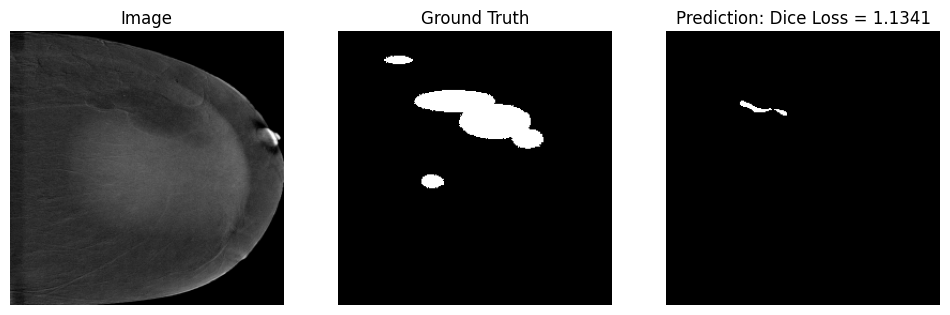

In [33]:
# visualisation of the model. 
idx = np.random.choice(len(test_ds))
print(f"Showing test image {idx}")
img, mask = test_ds[idx]

model.eval()

with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    dice_loss = loss_fn(logits, mask.unsqueeze(0).to(device)).item()

    pred = torch.sigmoid(logits)
    pred = (pred > 0.5).float()

img = img.squeeze().cpu()
mask = mask.squeeze().cpu()
pred = pred.squeeze().cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred, cmap="gray")
plt.title(f"Prediction: Dice Loss = {dice_loss:.4f}")
plt.axis("off")

plt.show()

# To do list:
* Implementeer meer metrics dan alleen dice loss: Jaccard index, accuracy, pixel accuracy, prec/rec/f1?
* Kies om maybe te focussen op 1 soort scan ipv allebei, gwn checken of t model dan beter is, OF 2 seperate modellen trainen.
* Alle scans maybe zorgen dat ze links/rechts gemirrored zijn? En bijbehorende ground truth dus ook.
* Zoeken naar een beter Unet model?

	
## Data Citation
Khaled R., Helal M., Alfarghaly O., Mokhtar O., Elkorany A., El Kassas H., Fahmy A. Categorized Digital Database for Low energy and Subtracted Contrast Enhanced Spectral Mammography images [Dataset]. (2021) The Cancer Imaging Archive. DOI:  10.7937/29kw-ae92 

Khaled, R., Helal, M., Alfarghaly, O., Mokhtar, O., Elkorany, A., El Kassas, H., & Fahmy, A. Categorized contrast enhanced mammography dataset for diagnostic and artificial intelligence research. (2022) Scientific Data, Volume 9, Issue 1. DOI: 10.1038/s41597-022-01238-0

Clark K, Vendt B, Smith K, Freymann J, Kirby J, Koppel P, Moore S, Phillips S, Maffitt D, Pringle M, Tarbox L, Prior F. The Cancer Imaging Archive (TCIA): Maintaining and Operating a Public Information Repository, Journal of Digital Imaging, Volume 26, Number 6, December, 2013, pp 1045-1057. DOI: 10.1007/s10278-013-9622-7